# P1 실습: 다층 퍼셉트론

**감사의 글**

아래 내용은 프랑소와 숄레의 
[Deep Learning with Python(3판)](https://github.com/fchollet/deep-learning-with-python-notebooks)의 
소스코드 내용을 참고해서 작성되었습니다.
자료를 공개한 저자에게 진심어린 감사를 전합니다.

**코드 실행**

[(구글 코랩) P1 실습: 다층 퍼셉트론](https://colab.research.google.com/github/codingalzi/code-workout-dlp/blob/master/P1_lab_mlp.ipynb)에서 코드를 실행할 수 있다.

**주요 내용**

이 실습에서는 강의에서 배운 다층 퍼셉트론 모델을 **MNIST 손글씨 숫자 분류 문제**에 직접 적용한다.

목표는 코드를 처음부터 작성하는 것이 아니라, 코드를 실행하면서 다음 흐름을 확인하는 것이다.

> **데이터 확인 → 입력 준비 → 모델 구성 → 훈련 → 예측 → 평가 → 오류 확인**

**설정: TensorFlow와 Keras의 GPU 사용 가능 여부 확인**

In [1]:
# TensorFlow 를 사용할 때 기타 정보 표시 제한. Tensorflow를 불러오기 전에 실행해야 함
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
import torch

# TensorFlow
tf_gpus = tf.config.list_physical_devices("GPU")

print("=== TensorFlow ===")
print("Version:", tf.__version__)
print("GPU 사용 가능:", len(tf_gpus) > 0)
if tf_gpus:
    print("GPU:", tf_gpus[0].name)

print()

# PyTorch
print("=== PyTorch ===")
print("Version:", torch.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

=== TensorFlow ===
Version: 2.20.0
GPU 사용 가능: True
GPU: /physical_device:GPU:0

=== PyTorch ===
Version: 2.9.1+cu128
GPU 사용 가능: True
GPU: NVIDIA RTX A6000
CUDA version: 12.8


## MNIST 데이터

MNIST는 `0`부터 `9`까지의 손글씨 숫자 이미지 데이터다.

- 훈련 이미지: 60,000장
- 테스트 이미지: 10,000장
- 이미지 한 장의 크기: `28 × 28`
- 타깃: 숫자 `0`부터 `9`

### MNIST 데이터 불러오기

먼저 데이터를 불러오고 shape을 확인한다.

In [2]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images :", test_images.shape)
print("test_labels :", test_labels.shape)

train_images: (60000, 28, 28)
train_labels: (60000,)
test_images : (10000, 28, 28)
test_labels : (10000,)


### MNIST 데이터 구조

`train_images.shape = (60000, 28, 28)`과  
`train_labels.shape = (60000,)`은 각각 무엇을 의미하는가?

두 shape의 첫 번째 숫자 `60000`은 어떤 관계를 나타내는가?

<details>
<summary><strong>해설 보기</strong></summary>

`train_images.shape = (60000, 28, 28)`은 60,000장의 이미지가 있고 각 이미지가 `28 × 28` 크기라는 뜻이다.

`train_labels.shape = (60000,)`은 각 이미지에 대응하는 타깃이 60,000개 있다는 뜻이다.

즉 **입력 샘플 수와 타깃 수가 서로 일치해야 한다.**

</details>

## 실제 이미지와 타깃 확인

### 실제 이미지 샘플 확인

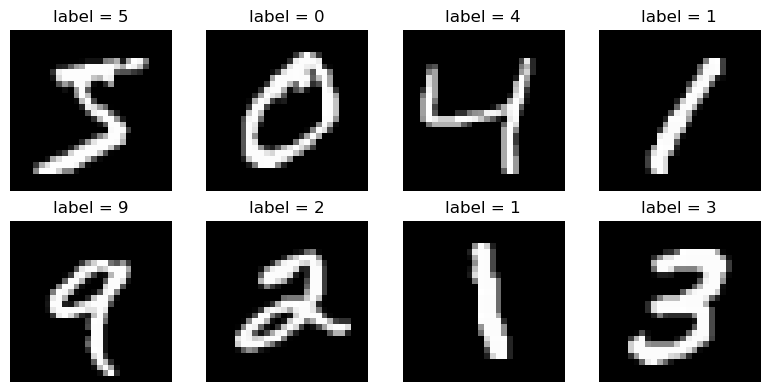

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 4))

for i in range(8):
    ax = fig.add_subplot(2, 4, i + 1)
    ax.imshow(train_images[i], cmap="gray")
    ax.set_title(f"label = {train_labels[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 입력과 타깃 확인

이미지와 타깃을 함께 보면서 다음을 확인해보자.

- 입력은 무엇인가?
- 타깃은 무엇인가?
- 왜 이 문제는 다중 클래스 분류 문제인가?

<details>
<summary><strong>해설 보기</strong></summary>

입력은 손글씨 숫자 이미지이고, 타깃은 `0`부터 `9`까지의 숫자다.  
10개의 범주 가운데 하나를 예측하므로 다중 클래스 분류 문제다.

</details>

## 완전연결층에 맞는 입력 데이터

MNIST 이미지 한 장의 원래 shape은 `(28, 28)`이다.

### 데이터 변환

하지만 이번에 사용할 `Dense` 층은 **완전연결층**이므로 이미지의 픽셀을 
하나의 벡터, 즉 1차원 어레이 형식으로 펼쳐서 입력해야 한다.

> `(28, 28) → (784,)`

또한 픽셀값의 범위를 `0~255`에서 `0~1`로 정규화한다.

입력값의 크기를 적절한 범위로 조정하면 신경망 훈련을 보다 안정적으로 진행할 수 있다.

In [4]:
print("변환 전:", train_images.shape)
print("픽셀값 범위:", train_images.min(), "~", train_images.max())

train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

print("변환 후:", train_images.shape)
print("픽셀값 범위:", train_images.min(), "~", train_images.max())

변환 전: (60000, 28, 28)
픽셀값 범위: 0 ~ 255
변환 후: (60000, 784)
픽셀값 범위: 0.0 ~ 1.0


### reshape이란?

1. reshape 전후에 이미지 한 장에 들어 있는 값의 개수는 달라졌는가?
2. 왜 `(28, 28)`을 `(784,)`로 바꾸는가?
3. reshape는 이미지의 정보를 없애는가, 아니면 배열의 모양만 바꾸는가?
4. `/ 255`는 무엇을 바꾸는가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 값의 개수는 변하지 않는다. `28 × 28 = 784`이다.
2. 완전연결층에 784개의 픽셀값을 하나의 입력 벡터로 전달하기 위해서다.
3. 픽셀값 자체는 없어지지 않지만, `(28, 28)`이라는 **2차원 공간 구조는 벡터 형태에서는 직접 드러나지 않는다.**
4. 픽셀값의 범위를 `0~255`에서 `0~1`로 바꾼다.

</details>

## Keras로 첫 신경망 구성

### 모델 구성

강의에서 본 기본 신경망을 그대로 사용한다.

> **784개의 입력값 → 512개의 은닉 유닛 → 10개의 출력값**

In [5]:
from keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

### 모델 구조 확인

In [6]:
model.build(input_shape=(None, 28 * 28))
model.summary()

I0000 00:00:1789565429.876657   64232 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46007 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

`model.summary()`를 보고 확인해보자.

1. 첫 번째 `Dense` 층의 출력 크기는 얼마인가?
2. 마지막 `Dense` 층의 출력이 10개인 이유는 무엇인가?
3. 강의에서 계산한 파라미터 수와 `model.summary()`의 값이 일치하는가?
4. 첫 번째 `Dense` 층의 파라미터 수가 두 번째 `Dense` 층보다 훨씬 많은 이유는 무엇인가?

<details>
<summary><strong>해설 보기</strong></summary>

- 첫 번째 `Dense` 층은 512개의 값을 출력한다.
- MNIST의 숫자 범주가 10개이므로 마지막 출력도 10개다.
- 첫 층의 파라미터 수는 `784 × 512 + 512`, 두 번째 층은 `512 × 10 + 10`이다.
- 첫 번째 층은 **784개의 입력값과 512개의 출력 유닛이 모두 연결**되기 때문에 훨씬 많은 가중치가 필요하다.

</details>

## 신경망 모델 훈련 준비

모델을 훈련하려면 다음 세 가지를 지정한다.

- **optimizer**: 파라미터를 어떻게 갱신할지 결정
- **loss**: 예측이 얼마나 틀렸는지 측정
- **metric**: 성능을 어떤 지표로 확인할지 결정

지금은 각 이름을 외우기보다 **코드에서 어떤 역할을 맡는지** 확인한다.

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 신경망 모델 훈련

### 검증 데이터 활용

훈련 과정에서 일부 훈련 데이터를 **검증 데이터**로 분리한다.

훈련 정확도만 보는 것이 아니라, 학습하지 않은 검증 데이터에서도 성능이 어떻게 변하는지 함께 확인하기 위해서다.

In [8]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
109/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7537 - loss: 0.8635

I0000 00:00:1789565433.090478   69577 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9153 - loss: 0.2978 - val_accuracy: 0.9547 - val_loss: 0.1578
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9646 - loss: 0.1229 - val_accuracy: 0.9668 - val_loss: 0.1132
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0820 - val_accuracy: 0.9725 - val_loss: 0.0897
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9835 - loss: 0.0563 - val_accuracy: 0.9753 - val_loss: 0.0834
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0410 - val_accuracy: 0.9760 - val_loss: 0.0808
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9914 - loss: 0.0308 - val_accuracy: 0.9770 - val_loss: 0.0776
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9938 - loss: 0.0233 - val_accuracy: 0.9780 - val_loss: 0.0752
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9956 - loss: 0.0181 - val_accuracy: 0.9763 - val_

### 훈련 로그 읽기

훈련 결과에서 다음을 찾아보자.

- `loss`
- `accuracy`
- `val_loss`
- `val_accuracy`

그리고 에포크가 진행되면서 각각 어떻게 변하는지 관찰한다.

### 모델 훈련 과정 시각화

- 정확도의 변화

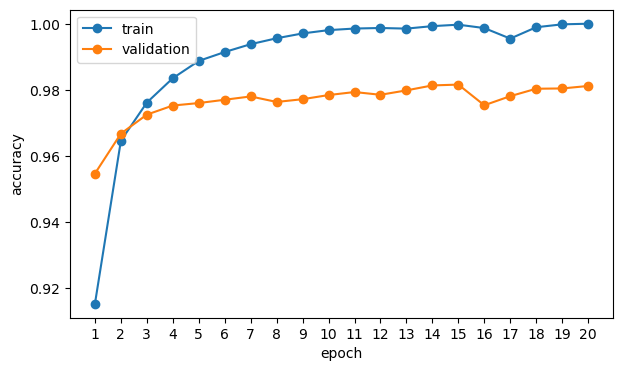

In [9]:
plt.figure(figsize=(7, 4))

epochs = range(1, len(history.history["accuracy"]) + 1)

plt.plot(epochs, history.history["accuracy"], marker="o", label="train")
plt.plot(epochs, history.history["val_accuracy"], marker="o", label="validation")

plt.xticks(range(1, len(history.history["accuracy"]) + 1))
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

- 손실값의 변화

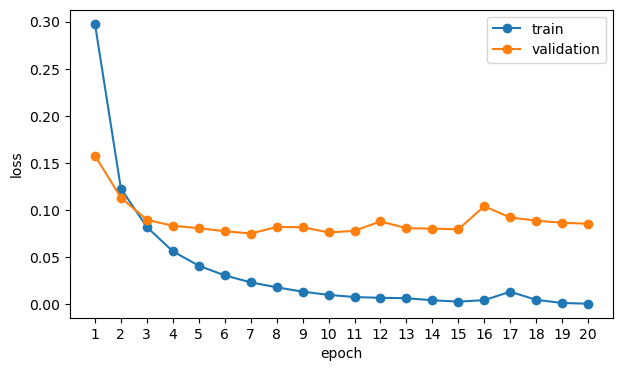

In [10]:
plt.figure(figsize=(7, 4))

epochs = range(1, len(history.history["loss"]) + 1)

plt.plot(epochs, history.history["loss"], marker="o", label="train")
plt.plot(epochs, history.history["val_loss"], marker="o", label="validation")

plt.xticks(range(1, len(history.history["loss"]) + 1))
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

훈련 정확도와 손실값이 검증 정확도와 손실값과 다르게 변한다.

훈련 정확도는 에포크가 증가하면서 계속 높아지고, 검증 정확도는 어느 순간부터 증가 속도가 둔화되거나 조금 낮아진다.

반면에 훈련 손실값은 에포크가 증가하면서 계속 낮아지고, 검증 손실값은 어느 순간부터 증가 속도가 둔화되거나 조금 높아진다.

### 콜백 활용

이전 훈련은 지정된 에포크값인 20회 동안 훈련이 진행된 후에 종료되었다.
하지만 검증 손실값을 기준으로 보았을 때 최고의 성능은 20 에포크까지 훈련된 모델이 아니라 6에서 11 에포크 정도 훈련된 모델이다.

이런 사실을 바탕으로 모델 훈련을 20 에포크보다 훨씬 적게 다시 처음부터 훈련을 시작할 수 있다.

하지만 그 보다는, 예를 들어, 검증 손실값을 기준으로 3회 이상 더 낮아지지 않으면 훈련을 멈추고 
그때까지 가장 좋은 성능을 내는 모델 파라미터로 되돌리는 **콜백**(callback) 기능이 추천된다.

훈련 설정을 바꿔 훈련을 진행하려면 모델 선언과 컴파일을 새롭게 지정해야 함에 주의한다.
그렇지 않으면 이전에 훈련된 모델이 이어서 훈련되기 때문이다.

In [37]:
from keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

아래 코드는 조기종료 기능과 에포크가 진행될 때마다 그때까지 최고의 성능을 보이는 모델 파라미터를 저장하는 기능의 콜백 두 개를 지정한다.

In [38]:
from keras import callbacks

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

checkpoint = callbacks.ModelCheckpoint(
    filepath="best_mlp.keras",
    monitor="val_loss",
    save_best_only=True,
)

In [39]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping, checkpoint],
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9170 - loss: 0.2920 - val_accuracy: 0.9548 - val_loss: 0.1608
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9647 - loss: 0.1217 - val_accuracy: 0.9687 - val_loss: 0.1080
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9778 - loss: 0.0786 - val_accuracy: 0.9710 - val_loss: 0.0945
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9830 - loss: 0.0572 - val_accuracy: 0.9757 - val_loss: 0.0808
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9887 - loss: 0.0409 - val_accuracy: 0.9762 - val_loss: 0.0791
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0304 - val_accuracy: 0.9778 - val_loss: 0.0731
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9944 - loss: 0.0227 - val_accuracy: 0.9783 - val_loss: 0.0748
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9956 - loss: 0.0179 - val_accuracy: 0.

20 에포크보다 훨씬 이전에 훈련이 종료되었다. 
`val_loss` 값이 마지막 에포크보다 3을 뺀 에포크까지 훈련된 모델이 최저 검증 손실값을 보여준다.

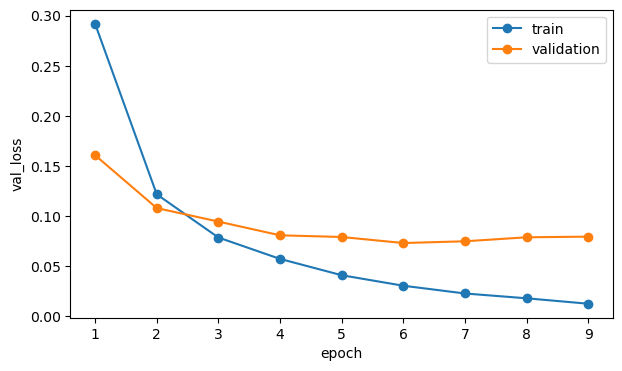

In [40]:
plt.figure(figsize=(7, 4))

epochs = range(1, len(history.history["loss"]) + 1)

plt.plot(epochs, history.history["loss"], marker="o", label="train")
plt.plot(epochs, history.history["val_loss"], marker="o", label="validation")

plt.xticks(range(1, len(history.history["loss"]) + 1))
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.legend()
plt.show()

## 새로운 데이터 예측

최고 성능의 모델의 성능을 테스트 이미지를 이용하여 평가한다.

먼저 조기 종료 기능의 `restore_best_weights=True` 옵션으로 `model`은 이미 최고 성능을 내는 파라미터로 되돌려져 있다.

In [41]:
best_model = model

하지만 `ModelCheckpoint` 콜백 기능에 의해 생성된 `best_mlp.keras` 파일에 저장된 파라미터를 불러와도 된다.

In [42]:
best_model = keras.models.load_model("best_mlp.keras") # best_model = model 이라고 해도 됨.

### `predict()` 메서드 활용

테스트 이미지 몇 장에 대해 모델의 출력을 확인한다.

출력은 10개의 값이며, 각 값은 숫자 `0`부터 `9`에 대응한다.

In [43]:
predictions = best_model.predict(test_images[:10], verbose=0)

i = 0
print("10개 출력:", predictions[i])
print("예측 숫자:", predictions[i].argmax())
print("가장 큰 출력값:", predictions[i].max())
print("실제 정답:", test_labels[i])

10개 출력: [1.7351530e-07 1.5309787e-08 4.6056366e-06 9.7434182e-05 1.3921346e-10
 1.2101358e-07 7.9380766e-11 9.9989164e-01 2.1901124e-06 3.9043312e-06]
예측 숫자: 7
가장 큰 출력값: 0.99989164
실제 정답: 7


다음 질문에 답해보자.

1. `predictions` 변수에는 어떤 값들이 저장되어 있는가?
2. `predictions[0]`의 10개 값은 각각 무엇을 의미하는가?
3. `argmax()`는 어떤 역할을 하는가?
4. 가장 큰 값만 보는 것과 10개 출력값 전체를 보는 것은 어떤 차이가 있는가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 처음 10개의 테스트 이미지에 대한 예측값으로 구성된 (10, 10) 모양의 2차원 어레이다.
2. 10개 출력값은 숫자 `0`부터 `9`까지 각 범주에 대응한다.
3. `argmax()`는 10개 출력값 가운데 가장 큰 값의 위치를 찾아 최종 예측 범주를 정한다.
4. 가장 큰 값만 보면 최종 예측만 알 수 있지만, 10개 값을 함께 보면 모델이 다른 숫자들에 어느 정도의 값을 주었는지도 확인할 수 있다.

</details>

즉, 한 이미지의 예측 과정은 다음과 같이 읽을 수 있다.

> **이미지 → 784개 입력값 → 신경망 → 10개 출력 → 가장 큰 값의 위치 → 예측 숫자**


### 예측값을 이미지와 함께 확인

첫 번째 테스트 이미지는 숫자 7처럼 보인다.

예측값도 숫자 7이다.

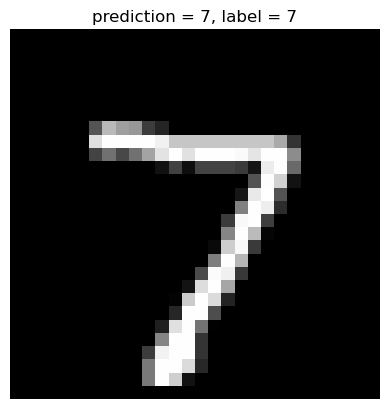

In [44]:
# 원래 모양으로 되돌려 시각화
image = test_images[0].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(
    f"prediction = {predictions[0].argmax()}, " # 예측값
    f"label = {test_labels[0]}"                 # 실제 정답 라벨
)
plt.axis("off")
plt.show()

## 모델 성능 최종 평가

훈련에 사용하지 않은 테스트 데이터 전체에서 모델의 성능을 확인한다.

In [45]:
test_loss, test_acc = best_model.evaluate(
    test_images,
    test_labels,
    batch_size=128,
)

print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9784 - loss: 0.0685
test loss     : 0.0685
test accuracy : 0.9784


앞서 말했듯 최고 성능의 모델의 파라미터는 조기 종료 콜백의 `restore_best_weights=True` 설정에 의해
`model`에 자동 저장된다.

즉, `best_model`과 `model`의 성능이 동일하다.

In [46]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    batch_size=128,
)

print(f"test loss     : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9784 - loss: 0.0685
test loss     : 0.0685
test accuracy : 0.9784


## PyTorch 다층 퍼셉트론

Keras의 MNIST 신경망 모델과 동일한 모델을 PyTorch로 표현하여 훈련시킨다.

목표는 새로운 딥러닝 원리를 배우는 것이 아니라,

> **Keras에서 사용한 구조와 훈련 과정이 PyTorch에서는 어떻게 드러나는가?**

를 확인하는 것이다.

Keras에서 사용한 구조는 다음과 같았다.

> **784개의 입력값 → 512개의 은닉 유닛 → 10개의 출력값**

### PyTorch의 MNIST 신경망 모델

In [47]:
import torch
from torch import nn

torch_model = nn.Sequential(
    nn.Linear(28 * 28, 512),
    nn.ReLU(),
    nn.Linear(512, 10),
)

torch_model

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)

### 신경망 모델 구조 비교

Keras와 PyTorch에서 대응하는 요소를 찾아보자.

| 개념 | Keras | PyTorch |
|---|---|---|
| 완전연결층 | `Dense` | `nn.Linear` |
| ReLU | `activation="relu"` | `nn.ReLU()` |
| 모델 연결 | `Sequential` | `nn.Sequential` |
| 출력 수 | 10 | 10 |

두 프레임워크의 문법은 다르지만 **모델의 구조 자체는 같다.**

다음 질문에 답해보자.

1. `nn.Linear(28 * 28, 512)`에서 두 숫자는 각각 무엇을 뜻하는가?
2. 마지막 층의 출력이 10개인 이유는 Keras와 동일한가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 784개의 입력값을 받아 512개의 값을 출력한다는 뜻이다.
2. 동일하다. MNIST에서 예측해야 하는 숫자 범주가 10개이기 때문이다.

</details>

## PyTorch에서 데이터 배치 준비

### 배치 묶음 데이터 생성

PyTorch에서는 데이터와 타깃을 `Tensor`로 만들고, `DataLoader`를 이용해 **배치 단위**로 전달하는 방식이 일반적이다.

앞에서 Keras용으로 `(60000, 784)` 형태로 준비한 데이터를 그대로 이용한다.

In [48]:
from torch.utils.data import TensorDataset, DataLoader

x_train_t = torch.tensor(train_images, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)

x_test_t = torch.tensor(test_images, dtype=torch.float32)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
)

### 배치 shape

PyTorch의 `DataLoader`는 데이터를 지정한 배치 크기만큼 묶어 **배치 단위로 전달할 준비를 하는 객체**다.

현재 `batch_size=128`이므로 훈련 과정에서는 한 번에 128개의 샘플이 전달된다.

- 입력 배치: `(128, 784)`
- 타깃 배치: `(128,)`

타깃 배치의 shape이 `(128,)`인 이유를 설명해보자.

<details>
<summary><strong>해설 보기</strong></summary>

각 입력 샘플 하나에 숫자 타깃 하나가 대응하므로, 128개 입력 샘플에 대해 128개의 타깃이 존재한다.

</details>

즉, Keras에서는 `fit()`을 호출하면 이러한 **배치 구성과 배치 단위 데이터 전달을 내부에서 처리**하는 반면에,
PyTorch에서는 `DataLoader`를 사용하여 이 과정을 코드에서 명시적으로 준비해야 한다.

## PyTorch의 훈련 루프

Keras에서는 `model.fit()`이 훈련 과정을 내부에서 처리했다.

PyTorch에서는 아래 훈련 과정을 코드에서 직접 구현한다.

> **gradient 초기화 → 순전파 → loss 계산 → 역전파 → 파라미터 갱신**

또한 Keras와 달리 PyTorch에서는 GPU 또는 CPU 중 어떤 **device**를 사용할지 명시적으로 지정한다.

훈련을 시작하기 전에 모델을 해당 device로 이동하고, 각 배치의 입력 데이터와 타깃도 같은 device로 이동하여 계산한다.

PyTorch에서는 훈련을 시작할 때

```python
torch_model.train()
```

을 사용하여 모델을 **훈련 모드**로 설정한다.

이와 대응하여 모델을 평가할 때는

```python
torch_model.eval()
```

을 사용하여 **평가 모드**로 전환한다.

즉 PyTorch에서는 Keras가 내부에서 처리하는 여러 과정을 코드에서 보다 명시적으로 확인할 수 있다.

In [49]:
# 훈련 device 지정: GPU 또는 CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", device)

# PyTorch 모델을 device로 이동
torch_model = torch_model.to(device)

# 손실 함수와 옵티마이저 정의
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters())

# 훈련 루프
epochs = 20  # 에포크 수

for epoch in range(epochs):
    torch_model.train()                   # 모델을 훈련 모드로 설정

    running_loss = 0.0                    # 에포크 내 누적 손실 초기화 (에포크 손실값 계산)
    correct = 0                           # 에포크 내 누적 정답 개수 초기화 (에포크 정확도 계산)
    total = 0                             # 에포크 내 누적 샘플 수 초기화

    # 배치 훈련
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)      # 입력 데이터를 GPU 또는 CPU로 이동
        y_batch = y_batch.to(device)      # 타깃 데이터를 GPU 또는 CPU로 이동

        optimizer.zero_grad()

        outputs = torch_model(x_batch)
        loss = loss_fn(outputs, y_batch)

        loss.backward()
        optimizer.step()

        # 배치 손실 누적
        running_loss += loss.item() * x_batch.size(0)
        # 정답 수 누적
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        # 배치 샘플 수 누적 (에포크 내에서 훈련된 샘플 수)
        total += y_batch.size(0)

    epoch_loss = running_loss / total     # 에포크 평균 손실 계산
    epoch_acc = correct / total           # 에포크 정확도 계산

    print(
        f"epoch {epoch + 1}: "
        f"loss={epoch_loss:.4f}, accuracy={epoch_acc:.4f}"
    )

device: cuda
epoch 1: loss=0.3125, accuracy=0.9166
epoch 2: loss=0.1245, accuracy=0.9640
epoch 3: loss=0.0799, accuracy=0.9760
epoch 4: loss=0.0585, accuracy=0.9829
epoch 5: loss=0.0445, accuracy=0.9867
epoch 6: loss=0.0330, accuracy=0.9907
epoch 7: loss=0.0252, accuracy=0.9935
epoch 8: loss=0.0187, accuracy=0.9952
epoch 9: loss=0.0165, accuracy=0.9955
epoch 10: loss=0.0123, accuracy=0.9968
epoch 11: loss=0.0095, accuracy=0.9978
epoch 12: loss=0.0064, accuracy=0.9987
epoch 13: loss=0.0066, accuracy=0.9984
epoch 14: loss=0.0080, accuracy=0.9979
epoch 15: loss=0.0066, accuracy=0.9981
epoch 16: loss=0.0028, accuracy=0.9995
epoch 17: loss=0.0027, accuracy=0.9994
epoch 18: loss=0.0109, accuracy=0.9967
epoch 19: loss=0.0044, accuracy=0.9989
epoch 20: loss=0.0012, accuracy=0.9999


다음 코드가 각각 어떤 역할을 하는지 연결해보자.

- `optimizer.zero_grad()`
- `outputs = torch_model(x_batch)`
- `loss = loss_fn(outputs, y_batch)`
- `loss.backward()`
- `optimizer.step()`

<details>
<summary><strong>해설 보기</strong></summary>

- `optimizer.zero_grad()`: 이전 배치에서 계산된 gradient를 초기화한다.
- `torch_model(x_batch)`: 현재 파라미터로 예측값을 계산한다.
- `loss_fn(...)`: 예측과 타깃의 차이를 측정한다.
- `loss.backward()`: loss를 기준으로 gradient를 계산한다.
- `optimizer.step()`: 계산된 gradient를 이용해 파라미터를 갱신한다.

</details>

Keras의 `fit()`에서는 이 과정이 내부에 숨겨져 있지만, PyTorch에서는 훈련 과정이 코드에 직접 드러난다.

## PyTorch 모델 평가

훈련이 끝난 뒤에는 테스트 데이터에서 정확도를 확인한다.

평가할 때는

- `model.eval()`
- `torch.no_grad()`

를 사용한다.

평가도 테스트 데이터를 배치 단위로 처리하고, 전체 샘플에 대한 정확도를 계산한다.

In [50]:
torch_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = torch_model(x_batch)
        predictions_t = outputs.argmax(dim=1)

        correct += (predictions_t == y_batch).sum().item()
        total += y_batch.size(0)

torch_test_acc = correct / total

print(f"PyTorch test accuracy: {torch_test_acc:.4f}")

PyTorch test accuracy: 0.9825


다음 두 질문에 답해보자.

1. `torch_model.eval()`은 왜 필요한가?
2. 평가할 때 `torch.no_grad()`를 사용하는 이유는 무엇인가?

<details>
<summary><strong>해설 보기</strong></summary>

1. 모델을 훈련 모드가 아닌 평가 모드로 전환한다.
2. 평가에서는 파라미터를 갱신하지 않으므로 gradient 계산이 필요하지 않다.

</details>

## Keras와 PyTorch 비교

같은 MNIST 문제를 두 프레임워크로 실행했다.

핵심 차이는 **딥러닝 원리**가 아니라 **코드를 표현하는 방식**이다.

| 과정 | Keras | PyTorch |
|---|---|---|
| 모델 구성 | `Dense`, `Sequential` | `nn.Linear`, `nn.Sequential` |
| 손실함수 | `compile(loss=...)` | `nn.CrossEntropyLoss()` |
| optimizer | `compile(optimizer=...)` | `torch.optim.Adam(...)` |
| 훈련 | `fit()` | 명시적인 반복문 |
| 예측 | `predict()` | `model(x)` |
| 평가 모드 | 내부 처리 | `model.eval()` |
| gradient 비활성화 | 내부 처리 | `torch.no_grad()` |

> **Keras와 PyTorch는 서로 다른 딥러닝이 아니라, 같은 딥러닝 원리를 서로 다른 방식으로 표현하는 프레임워크다.**

특히 PyTorch에서는 훈련 루프가 코드에 직접 드러나므로, 강의에서 배운 **순전파 → loss → 역전파 → 파라미터 갱신**을 확인하기 좋다.

## 실습 정리

이번 실습에서는 MNIST를 이용해 하나의 기본 신경망을 **Keras와 PyTorch 두 방식으로 확인**했다.

Keras에서는

> **데이터 → 모델 → `compile()` → `fit()` → 예측 → 평가**

의 전체 흐름을 빠르게 확인했다.

PyTorch에서는 같은 모델을 다시 표현하면서

> **배치 → 순전파 → loss → 역전파 → optimizer에 의한 파라미터 갱신**

과정을 코드에서 직접 확인했다.

다음 P1 프로젝트에서는 같은 원리를 **Fashion-MNIST**에 적용한다.

그때는 단순히 실습 코드를 다시 실행하는 것이 아니라,

> **어떤 모델을 사용할 것인가? 결과를 어떻게 비교할 것인가? 무엇을 개선할 것인가?**

를 스스로 판단한다.

## 연습문제

파이토치 모델 훈련에 조기종료와 최적의 훈련 모델을 저장하는 기능을 추가하는 코드를 작성한 다음에 테스트 데이터에 대한 정확도를 계산해본다.

먼저 모델을 다시 정의한다.

In [54]:
import torch
from torch import nn

torch_model = nn.Sequential(
    nn.Linear(28 * 28, 512),
    nn.ReLU(),
    nn.Linear(512, 10),
)

torch_model

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)

훈련 데이터의 20%를 검증 데이터로 지정한다.

In [55]:
from torch.utils.data import DataLoader, TensorDataset, random_split

x_train_t = torch.tensor(train_images, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)

x_test_t = torch.tensor(test_images, dtype=torch.float32)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

full_train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset = TensorDataset(x_test_t, y_test_t)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

조기종료와 검증 데이터 기분 최고 성능의 모델을 저장하는 기능을 추가한 훈련 코드를 작성한다.

In [ ]:
from copy import deepcopy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model = torch_model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(torch_model.parameters())

epochs = 20
patience = 3
best_val_loss = float("inf")
best_model_state = None
wait = 0

for epoch in range(epochs):
    torch_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = torch_model(x_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    torch_model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = torch_model(x_batch)
            loss = loss_fn(outputs, y_batch)

            val_running_loss += loss.item() * x_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    print(
        f"epoch {epoch + 1}: "
        f"loss={train_loss:.4f}, accuracy={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_accuracy={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(torch_model.state_dict())
        torch.save(best_model_state, "best_torch_mlp.pt")
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

torch_model.load_state_dict(best_model_state)

epoch 1: loss=0.3480, accuracy=0.9056, val_loss=0.1949, val_accuracy=0.9445
epoch 2: loss=0.1445, accuracy=0.9574, val_loss=0.1327, val_accuracy=0.9626
epoch 3: loss=0.0946, accuracy=0.9730, val_loss=0.1118, val_accuracy=0.9684
epoch 4: loss=0.0693, accuracy=0.9798, val_loss=0.0968, val_accuracy=0.9704
epoch 5: loss=0.0501, accuracy=0.9859, val_loss=0.0896, val_accuracy=0.9748
epoch 6: loss=0.0389, accuracy=0.9890, val_loss=0.0832, val_accuracy=0.9769
epoch 7: loss=0.0283, accuracy=0.9928, val_loss=0.0821, val_accuracy=0.9769
epoch 8: loss=0.0222, accuracy=0.9944, val_loss=0.0849, val_accuracy=0.9758
epoch 9: loss=0.0175, accuracy=0.9954, val_loss=0.0825, val_accuracy=0.9765
epoch 10: loss=0.0133, accuracy=0.9971, val_loss=0.0816, val_accuracy=0.9789
epoch 11: loss=0.0100, accuracy=0.9981, val_loss=0.0827, val_accuracy=0.9782
epoch 12: loss=0.0079, accuracy=0.9985, val_loss=0.0813, val_accuracy=0.9784
epoch 13: loss=0.0066, accuracy=0.9989, val_loss=0.0901, val_accuracy=0.9775
epoch 14

<All keys matched successfully>